In [1]:
import onnxruntime as ort
import numpy as np
import cv2
from help_fun import *
from pathlib import Path
import os
import onnxruntime

In [2]:
def prepoces_image(image_path: Path) -> np.array:
    img = imread_rgb(image_path)
    img = cv2.resize(img, (640, 640))
    img = img.astype(np.float32) / 255
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    return img

In [3]:
folder_path = Path('bdd100k_data/bdd100k/bdd100k/images/100k/train')

image_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.png') or file.endswith('.jpg')]

In [4]:
inter = Inference("onnx_model/best.onnx")
boxes_and_classes = inter.pipeline(image_paths[0])

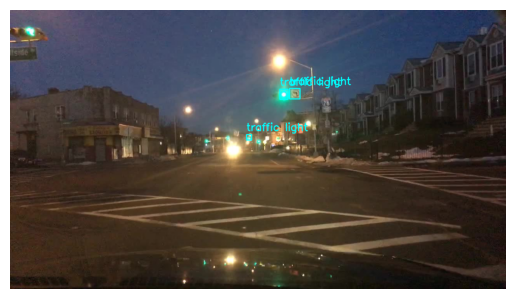

In [5]:
num = 0

img = imread_rgb(image_paths[num])

inter = Inference("onnx_model/best.onnx")
boxes_and_classes = inter.pipeline(image_paths[num])

inter.plot_bounding_box(image_paths[num])

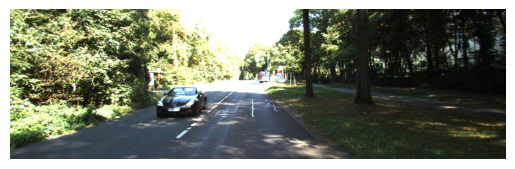

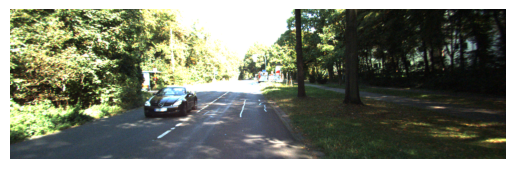

In [51]:
left_camera_path = Path('testing/image_2')
right_camera_path = Path('testing/image_3')

left_image_paths = [os.path.join(left_camera_path, p) for p in os.listdir(left_camera_path) if p.endswith('.png') or p.endswith('.jpg')]
right_image_paths = [os.path.join(right_camera_path, p) for p in os.listdir(right_camera_path) if p.endswith('.png') or p.endswith('.jpg')]

plot(imread_rgb(left_image_paths[0]))
plot(imread_rgb(right_image_paths[0]))

### Due to the fact that two cameras are at the same height (Y axis) we will look for bouder boxes only in the X axis (move them)

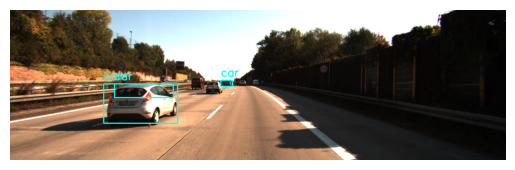

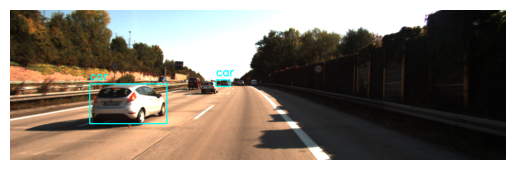

In [52]:
def cut_bounder_box(img_path: str) -> list:
    img, boxes_and_classes = inter.pipeline(img_path)
    bbs = []

    for bac in boxes_and_classes:
        x0, y0, h, w = bac.coord
        cls = bac.cls
        bb = img[y0:y0+w, x0:x0+h]

        xc, yc = (2*x0 + w)//2, (2*y0 + h)//2
        center = xc, yc

        bbs.append((bb, cls, center))

    return bbs

def expand_search_dim(coord: list, img_shape: list) -> list:
    x1, y1, h, w = coord
    img_h, img_w = img_shape
    x_new = x1 - w // 2
    y_new = y1 - h // 2

    w_new = 2 * w
    h_new = 2 * h

    x_new = max(0, x_new)
    y_new = max(0, y_new)

    if x_new + w_new > img_w:
        w_new = img_w - x_new
    if y_new + h_new > img_h:
        h_new = img_h - y_new

    return x_new, y_new, w_new, h_new

def is_point_inside_bbox(px, py, bbox):
    x0, y0, w, h = bbox
    return x0 <= px <= x0 + w and y0 <= py <= y0 + h


boxes_and_classes = inter.pipeline(left_image_paths[0])

inter.plot_bounding_box(left_image_paths[4])
inter.plot_bounding_box(right_image_paths[4])

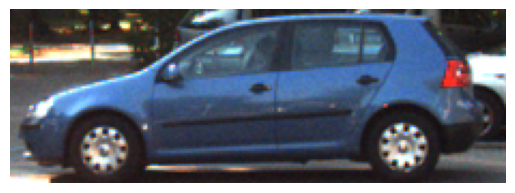

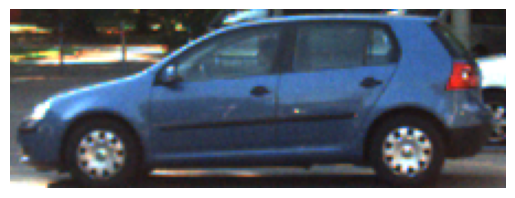

##############################


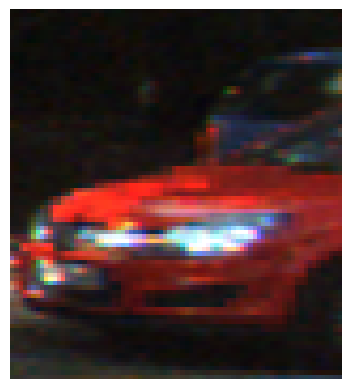

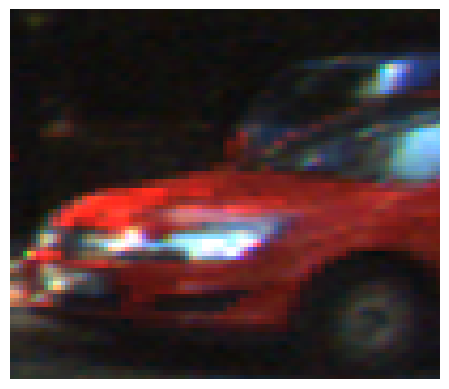

##############################


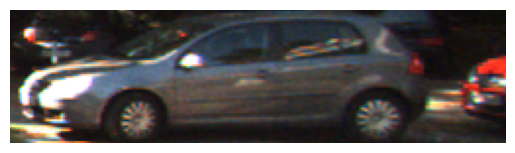

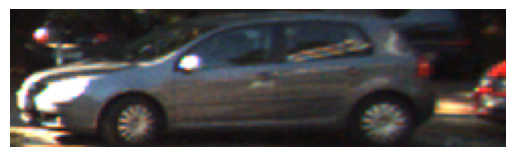

##############################


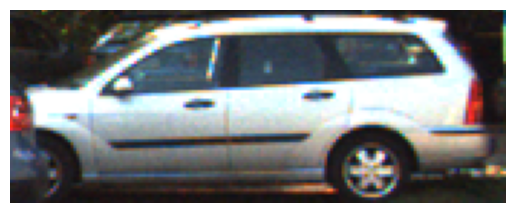

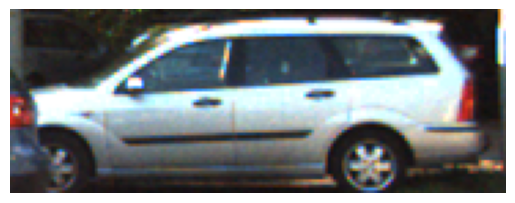

##############################


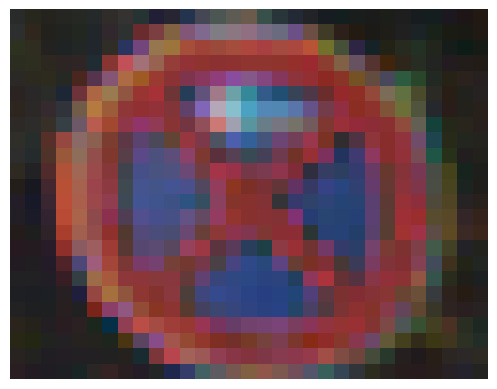

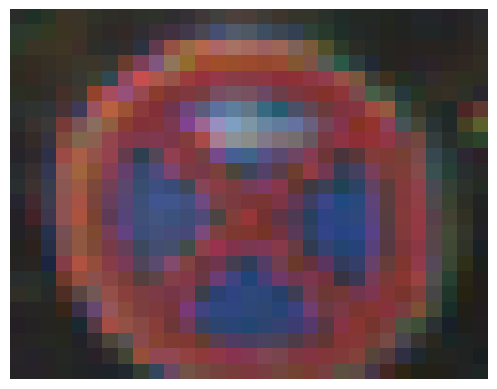

##############################


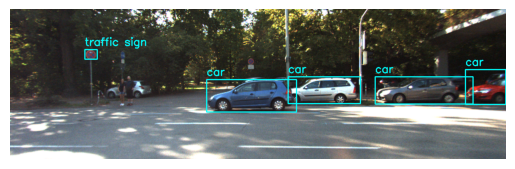

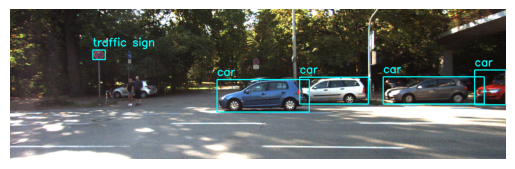

In [72]:
import concurrent.futures

class Embedded:
    def __init__(self, model_path: str):
        self.session = ort.InferenceSession(model_path)

    def __preprocess(self, img: np.array) -> np.array:
        image_data = cv2.resize(img, (64, 64))
        image_data = image_data.astype(np.float32) / 255.0
        image_data = np.transpose(image_data, (2, 0, 1))  
        image_data = np.expand_dims(image_data, axis=0)     
        return image_data
    
    def pipeline(self, img: np.array) -> np.array:
        img_pre = self.__preprocess(img)
        output = self.session.run(None, {'input': img_pre})[0]
        return output


class dualCameraTracing:
    def __init__(self, model_path: str, embedded_model_path: str):
        self.inter = Inference(model_path)
        self.embedded = Embedded(embedded_model_path)

    def find_same_object(self, img_pathR, img_pathL):
        imgR, coord_and_classesR = self.inter.pipeline(img_pathR)
        imgL, coord_and_classesL = self.inter.pipeline(img_pathL)

        bbsR = self.cut_bounding_box(imgR, coord_and_classesR, expand=True)
        bbsL = self.cut_bounding_box(imgL, coord_and_classesL, expand=True)

        self.compare_dict = {}

        # Process bounding boxes and find matching candidates
        self.compare_bboxes(bbsR, bbsL)

        # Fetch embeddings and calculate cosine similarity
        self.match_objects(bbsR, bbsL)

        self.inter.plot_bounding_box(img_pathR)
        self.inter.plot_bounding_box(img_pathL)

    def compare_bboxes(self, bbsR, bbsL):
        # Find the matching bounding boxes
        for idxR, bbR in enumerate(bbsR):
            _, _, _, coord_expR = bbR
            candidates = []
            for idxL, bbL in enumerate(bbsL):
                _, _, centerL, _ = bbL
                if self.is_point_inside_bbox(centerL[0], centerL[1], coord_expR):
                    candidates.append(idxL)
            self.compare_dict[idxR] = candidates

    def match_objects(self, bbsR, bbsL):
        matched = {}
        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = {}
            for idxR, candidates in self.compare_dict.items():
                futures[idxR] = executor.submit(self.find_best_match, idxR, candidates, bbsR, bbsL)
            for idxR, future in futures.items():
                matched[idxR] = future.result()

        # Plot matched bounding boxes
        for key, idx in matched.items():
            if idx is not None:
                plot(bbsL[idx][0])
            plot(bbsR[key][0])
            print('##############################')

    def find_best_match(self, idxR, candidates, bbsR, bbsL):
        embR = np.squeeze(self.embedded.pipeline(bbsR[idxR][0]), axis=0)
        best_score = 0.5
        best_idxL = None
        for idxL in candidates:
            embL = np.squeeze(self.embedded.pipeline(bbsL[idxL][0]), axis=0)
            score = self.cosine_similarity(embR, embL)
            if score > best_score:
                best_score = score
                best_idxL = idxL
        return best_idxL

    def cut_bounding_box(self, img: np.array, coord_and_classes: list, expand: bool) -> list:
        bbs = []
        for obj in coord_and_classes:
            x0, y0, w, h = obj.coord
            coord_expanded = self.expand_search_dim(obj.coord, img.shape) if expand else (x0, y0, w, h)
            cls = obj.cls
            bb_crop = img[y0:y0+h, x0:x0+w]
            center_x = x0 + w // 2
            center_y = y0 + h // 2
            center = (center_x, center_y)
            bbs.append((bb_crop, cls, center, coord_expanded))
        return bbs

    def expand_search_dim(self, coord: list, img_shape: list) -> list:
        x0, y0, w, h = coord
        img_h, img_w = img_shape[:2]
        x_new = max(0, x0 - w // 2)
        y_new = max(0, y0 - h // 2)
        w_new = min(2 * w, img_w - x_new)
        h_new = min(2 * h, img_h - y_new)
        return x_new, y_new, w_new, h_new

    def is_point_inside_bbox(self, px, py, bbox):
        x0, y0, w, h = bbox
        return x0 <= px <= x0 + w and y0 <= py <= y0 + h

    def cosine_similarity(self, emb1, emb2):
        return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

# Example usage
r_p = right_image_paths[5]
l_p = left_image_paths[5]

dct = dualCameraTracing('onnx_model/best.onnx', 'onnx_embbeded/mobilenet_v3_small_64x64_embed.onnx')
dct.find_same_object(r_p, l_p)


In [10]:
def iou_y(boxA, boxB):
    yA_top = boxA[1]
    yA_bottom = boxA[1] + boxA[3]
    yB_top = boxB[1]
    yB_bottom = boxB[1] + boxB[3]
    
    intersection = max(0, min(yA_bottom, yB_bottom) - max(yA_top, yB_top))
    union = max(yA_bottom, yB_bottom) - min(yA_top, yB_top)
    
    return intersection / union

def score_boxes(boxL, boxR, alpha=0.01, beta=0.01):
    if boxL.label == boxR.label:
        delta_class = 1
    else:
        delta_class = 0

    yL = boxL.coord[1]
    yR = boxR.coord[1]
    hL = boxL.coord[3]
    hR = boxR.coord[3]

    diff_y = abs(yL - yR)
    diff_h = abs(hL - hR)
    
    score = delta_class * np.exp(-alpha * diff_y) * np.exp(-beta * diff_h)
    
    return score

In [36]:

a = [1, 0, 0, 1]
b = [4, 1, 2, 2]
np.dot(a, b)

np.int64(6)

In [37]:
np.linalg.norm(a)

np.float64(1.4142135623730951)

In [ ]:
np.seq